In [35]:
# Preliminaries -----------------------------------------------------------
if (!require("pacman")) install.packages("pacman")
pacman::p_load(tidyverse, ggplot2, dplyr, lubridate, broom, kableExtra)

In [36]:
data <- read_csv("../data/output/combined_hcris_mcaid_new.csv")

data <- data %>%
  mutate(
    expanded = !is.na(expansion_date),
    date_adopted = as.Date(expansion_date)
  )

Rows: 161060 Columns: 46
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (10): provider_number, data_source, street, city, state, zip, county, n...
dbl  (31): beds, tot_charges, net_pat_rev, tot_discounts, tot_operating_exp,...
date  (5): fy_start, fy_end, date_processed, date_created, expansion_date

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


## Problem 1

Mean uncompensated care rose from 2010 to 2013 and declined slightly before spiking in 2016 and declining afterwards. Overall the trend is upward from 2010 to 2013, with notable fluctuation after 2014, which coincides with the rollout of Medicaid expansion.

In [37]:
data %>%
  filter(year >= 2010, year <= 2018) %>%
  group_by(year) %>%
  summarize(
    Mean = mean(uncomp_care / 1e6, na.rm = TRUE),
    N = sum(!is.na(uncomp_care / 1e6)),
    .groups = "drop"
  ) %>%
  kbl(
    digits = 5,
    col.names = c("Year", "Mean Uncompensated Care ($M)", "No. of Hospitals"),
    caption = " Mean Uncompensated Care by Year (2010–2018)"
  ) %>%
  kable_styling(full_width = FALSE)

<table class="table" style="width: auto !important; margin-left: auto; margin-right: auto;">
<caption> Mean Uncompensated Care by Year (2010–2018)</caption>
 <thead>
  <tr>
   <th style="text-align:right;"> Year </th>
   <th style="text-align:right;"> Mean Uncompensated Care ($M) </th>
   <th style="text-align:right;"> No. of Hospitals </th>
  </tr>
 </thead>
<tbody>
  <tr>
   <td style="text-align:right;"> 2010 </td>
   <td style="text-align:right;"> 30.02459 </td>
   <td style="text-align:right;"> 2816 </td>
  </tr>
  <tr>
   <td style="text-align:right;"> 2011 </td>
   <td style="text-align:right;"> 33.83339 </td>
   <td style="text-align:right;"> 2480 </td>
  </tr>
  <tr>
   <td style="text-align:right;"> 2012 </td>
   <td style="text-align:right;"> 37.26657 </td>
   <td style="text-align:right;"> 2617 </td>
  </tr>
  <tr>
   <td style="text-align:right;"> 2013 </td>
   <td style="text-align:right;"> 39.31041 </td>
   <td style="text-align:right;"> 2707 </td>
  </tr>
  <tr>
   <td 

## Problem 2 

The graph suggests a potential treatment effect. Prior to 2014, both groups follow a somewhat similar upward trend, which is consistent with the parallel trends assumption. After 2014, the two groups diverge, which is what we would expect if Medicaid expansion caused hospital expansion to receive more insured patients, which reduces the amount of uncompensated care hospitals provide. 

`summarise()` has regrouped the output.
ℹ Summaries were computed grouped by year and expand_group.
ℹ Output is grouped by year.
ℹ Use `summarise(.groups = "drop_last")` to silence this message.
ℹ Use `summarise(.by = c(year, expand_group))` for per-operation grouping
  (`?dplyr::dplyr_by`) instead.


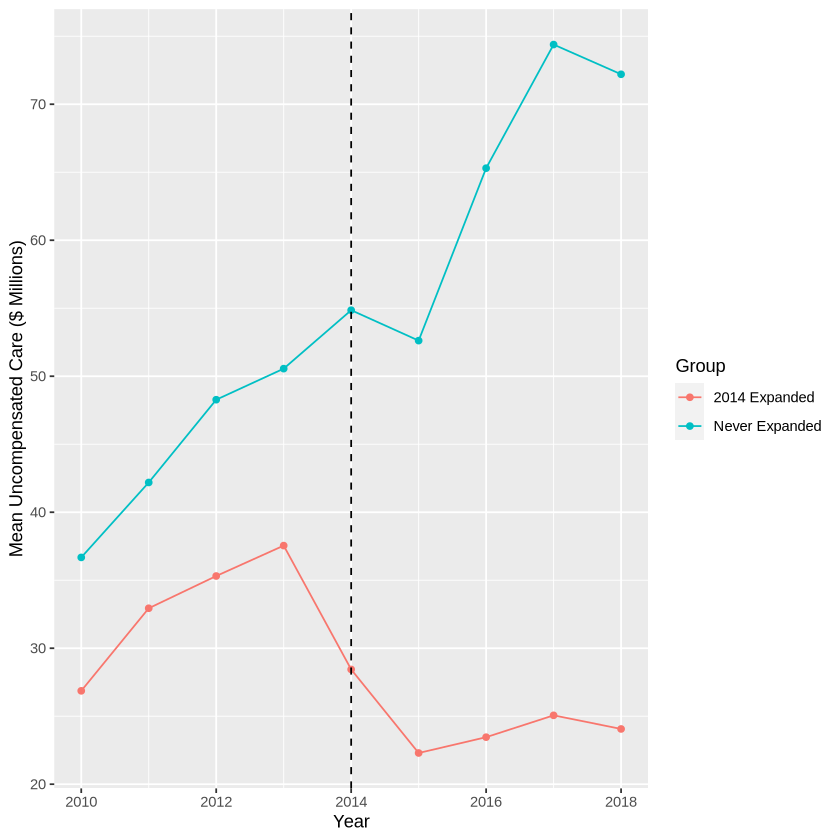

In [38]:
data_filtered <- data %>%
  filter(year >= 2010, year <= 2018) %>%
  mutate(expand_group = case_when(
    year(date_adopted) == 2014 ~ "2014 Expanded",
    is.na(date_adopted) ~ "Never Expanded"
  )) %>%
  filter(!is.na(expand_group))

data_filtered %>%
  group_by(year, expand_group) %>%
  summarise(mean_uncomp = mean(uncomp_care, na.rm = TRUE) / 1e6) %>%
  ggplot(aes(x = year, y = mean_uncomp, color = expand_group)) +
  geom_line() + geom_point() +
  geom_vline(xintercept = 2014, linetype = "dashed") +
  labs(x = "Year", y = "Mean Uncompensated Care ($ Millions)", color = "Group")


## Problem 3

In [39]:
library(kableExtra)

data_filtered %>%
  filter(year %in% c(2012, 2015)) %>%
  group_by(expand_group, year) %>%
  summarise(mean_uncomp = mean(uncomp_care, na.rm = TRUE) / 1e6) %>%
  pivot_wider(names_from = year, values_from = mean_uncomp) %>%
  kbl(
    digits = 2,
    col.names = c("Group", "2012", "2015"),
    caption = " Mean Uncompensated Care for Expansion vs Non-expansion States"
  ) %>%
 kable_styling(full_width = FALSE)

`summarise()` has regrouped the output.
ℹ Summaries were computed grouped by expand_group and year.
ℹ Output is grouped by expand_group.
ℹ Use `summarise(.groups = "drop_last")` to silence this message.
ℹ Use `summarise(.by = c(expand_group, year))` for per-operation grouping
  (`?dplyr::dplyr_by`) instead.


<table class="table" style="width: auto !important; margin-left: auto; margin-right: auto;">
<caption> Mean Uncompensated Care for Expansion vs Non-expansion States</caption>
 <thead>
  <tr>
   <th style="text-align:left;"> Group </th>
   <th style="text-align:right;"> 2012 </th>
   <th style="text-align:right;"> 2015 </th>
  </tr>
 </thead>
<tbody>
  <tr>
   <td style="text-align:left;"> 2014 Expanded </td>
   <td style="text-align:right;"> 35.31 </td>
   <td style="text-align:right;"> 22.30 </td>
  </tr>
  <tr>
   <td style="text-align:left;"> Never Expanded </td>
   <td style="text-align:right;"> 48.27 </td>
   <td style="text-align:right;"> 52.62 </td>
  </tr>
</tbody>
</table>

## Problem 4

Medicaid expansion decreases uncompensated care which is expected since Medicaid expansion extends coverage to a larger population. Before expansion, many low-income patients were uninsured and unable to pay for hospital services, forcing hospitals to absorb those costs as uncompensated care. With the Medicaid expansion, these patients gain Medicaid coverage, meaning hospitals can now bill Medicaid for services that previously went uncompensated. Thus, the volume of charity care and bad debt decreases.

## Problem 5

In [40]:
library(tidyverse)
library(fixest)
library(modelsummary)

In [41]:
reg_dat <- data %>%
  filter(as.Date(date_adopted) == as.Date("2014-01-01") | is.na(date_adopted)) %>%
  filter(uncomp_care > 0, !is.na(expanded)) %>%
  filter(year >= 2011, year <= 2018) %>%
  mutate(
    post  = (year >= 2014),
    treat = post * expanded
  )

m_dd <- lm(uncomp_care / 1e6 ~ post + expanded + treat, data = reg_dat)

modelsummary(list("Standard DD" = m_dd),
             coef_rename = c("postTRUE"     = "Post 2014",
                             "expandedTRUE" = "Expand",
                             "treat"        = "Post x Expand"),
             gof_map = c("nobs", "r.squared"),
             vcov = ~ state,
             output = "latex",
             title = "DD Estimates: Effect of Medicaid Expansion on Uncompensated Care ($M), 2014 Expanded vs Never Expanded"
            )

\begin{table}
\centering
\caption{DD Estimates: Effect of Medicaid Expansion on Uncompensated Care (\$M), 2014 Expanded vs Never Expanded}
\centering
\begin{tabular}[t]{lc}
\toprule
  & Standard DD\\
\midrule
(Intercept) & \num{47.478}\\
 & (\num{8.019})\\
Post 2014 & \num{15.691}\\
 & (\num{3.188})\\
Expand & \num{-10.879}\\
 & (\num{9.979})\\
Post x Expand & \num{-26.738}\\
 & (\num{4.042})\\
\midrule
Num.Obs. & \num{14550}\\
R2 & \num{0.022}\\
\bottomrule
\end{tabular}
\end{table}

## Problem 6

The effect of Medicaid expansion appears to be slightly larger once controlled for differences across hospitals and years. This makes sense because some hospitals can have larger or smaller amounts of uncompensated care regardless of expansion. Fixed effects removes this noise, but the two estimates are close, giving us confidence that the results are real. 

In [43]:
m_fe <- feols(uncomp_care / 1e6 ~ post + expanded + treat | provider_number + year,
              cluster = ~ state,
              data = reg_dat)

modelsummary(list("DD" = m_dd, "DD + FE" = m_fe),
             coef_rename = c("postTRUE"     = "Post 2014",
                             "expandedTRUE" = "Expand",
                             "treat"        = "Post x Expand"),
             gof_map = c("nobs", "r.squared", "r2.within"),
             vcov = list(~ state, ~ state),
             output = "latex",
             title = "DD Estimates with TWFE: Effect of Medicaid Expansion on Uncompensated Care ($M), 2014 Expanders vs Never Expanded"
            )

The variables 'postTRUE' and 'expandedTRUE' have been removed because of collinearity (see $collin.var).



\begin{table}
\centering
\caption{DD Estimates with TWFE: Effect of Medicaid Expansion on Uncompensated Care (\$M), 2014 Expanders vs Never Expanded}
\centering
\begin{tabular}[t]{lcc}
\toprule
  & DD & DD + FE\\
\midrule
(Intercept) & \num{47.478} & \\
 & (\num{8.019}) & \\
Post 2014 & \num{15.691} & \\
 & (\num{3.188}) & \\
Expand & \num{-10.879} & \\
 & (\num{9.979}) & \\
Post x Expand & \num{-26.738} & \num{-30.655}\\
 & (\num{4.042}) & (\num{5.849})\\
\midrule
Num.Obs. & \num{14550} & \num{14550}\\
R2 & \num{0.022} & \num{0.885}\\
R2 Within &  & \num{0.038}\\
\bottomrule
\end{tabular}
\end{table}

## Problem 7

When all states that expanded Medicaid are included, the TWFE effect is slightly smaller because states that expanded later had less time after expansion to see the full effect. But both estimates are in the same direction and close in magnitude. 

In [26]:
reg_dat_all <- data %>%
  filter(year >= 2010, year <= 2018) %>%
  filter(uncomp_care > 0, !is.na(expanded)) %>%
  mutate(
    expand_year = year(date_adopted),
    treat = case_when(
      year >= expand_year & !is.na(expand_year) ~ 1,
      is.na(expand_year) ~ 0,
      year < expand_year & !is.na(expand_year) ~ 0
    )
  )

m_ols_all <- lm(uncomp_care / 1e6 ~ treat, data = reg_dat_all)

m_fe_all <- feols(uncomp_care / 1e6 ~ treat | provider_number + year,
                  cluster = ~ state,
                  data = reg_dat_all)

modelsummary(
  list("OLS DiD" = m_ols_all, "TWFE" = m_fe_all),
  coef_map = c("treat" = "Post x Ever Expanded (DiD)"),
  gof_map = c("nobs", "r.squared", "r2.within"),
  vcov = list(~ state, ~ state),
  output = "latex",
  title = "OLS DiD and TWFE: Effect of Medicaid Expansion on Uncompensated Care ($M), All States"
)

\begin{table}
\centering
\caption{OLS DiD and TWFE: Effect of Medicaid Expansion on Uncompensated Care (\$M), All States}
\centering
\begin{tabular}[t]{lcc}
\toprule
  & OLS DiD & TWFE\\
\midrule
Post x Ever Expanded (DiD) & \num{-13.112} & \num{-24.459}\\
 & (\num{6.414}) & (\num{4.747})\\
\midrule
Num.Obs. & \num{23220} & \num{23220}\\
R2 & \num{0.001} & \num{0.418}\\
R2 Within &  & \num{0.002}\\
\bottomrule
\end{tabular}
\end{table}

## Problem 8

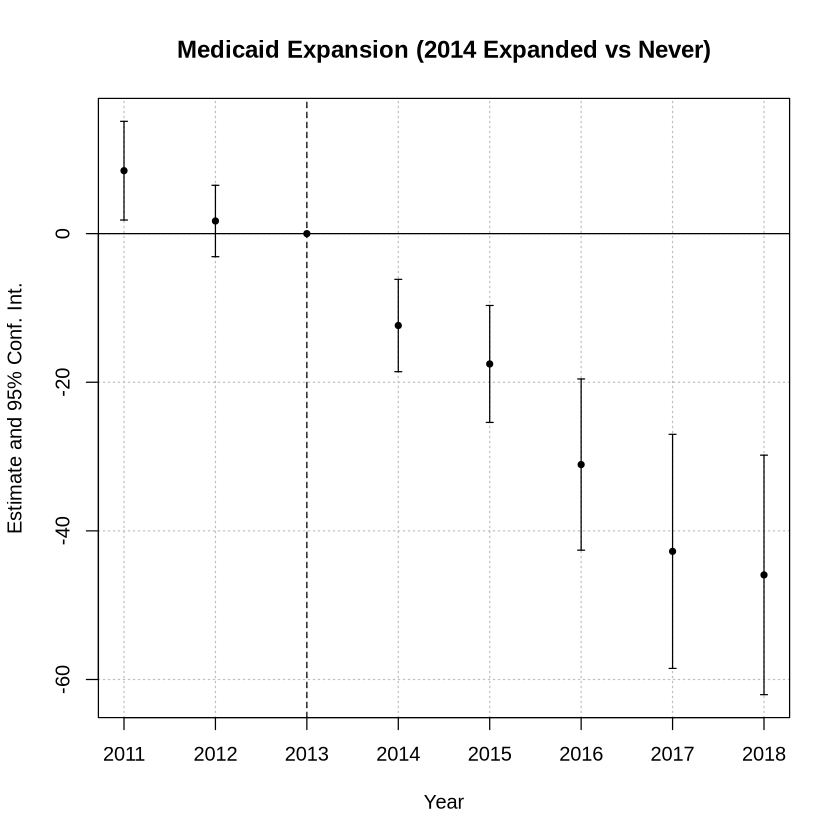

In [12]:
mod_es <- feols(uncomp_care / 1e6 ~ i(year, expanded, ref = 2013) | provider_number + year,
                cluster = ~ state,
                data = reg_dat)

iplot(mod_es, xlab = "Year", main = "Medicaid Expansion (2014 Expanded vs Never)")

## Problem 9

NOTE: 31,481 observations removed because of NA values (LHS: 31,481).



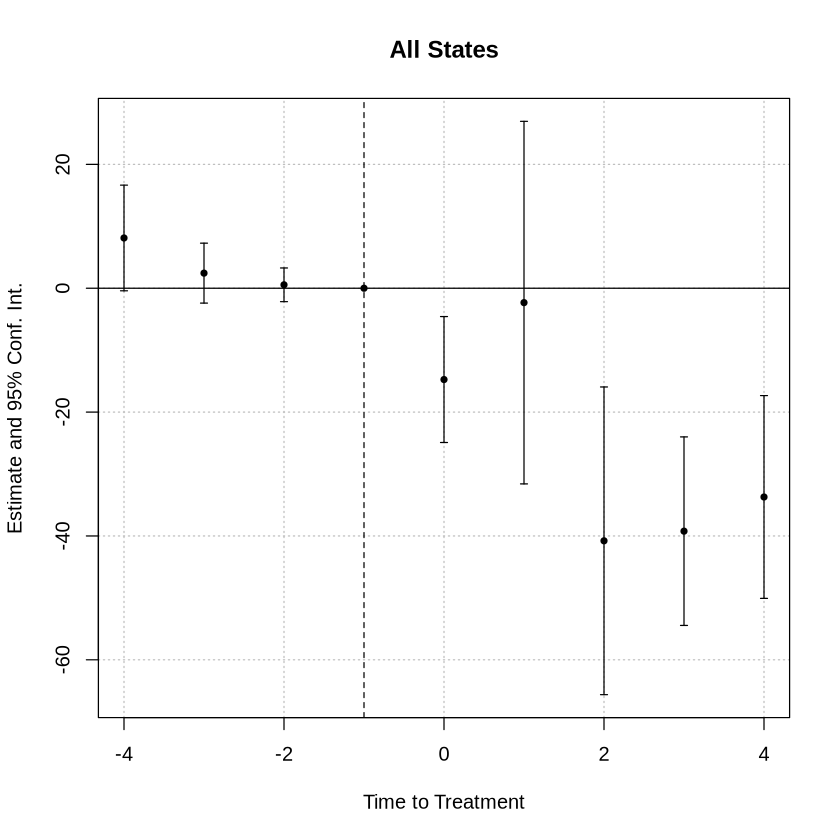

In [13]:
# Question 9: Event study with all states, event time variable, binned endpoints
reg_dat_full <- data %>%
  filter(year >= 2010, year <= 2018) %>%
  mutate(
    expand_year   = year(as.Date(date_adopted)),
    time_to_treat = ifelse(expanded == FALSE, -1, year - expand_year),
    time_to_treat = ifelse(time_to_treat < -4, -4, time_to_treat),
    time_to_treat = ifelse(time_to_treat > 4,   4, time_to_treat)
  )

mod_es_full <- feols(uncomp_care / 1e6 ~ i(time_to_treat, expanded, ref = -1) | provider_number + year,
                     cluster = ~ state,
                     data = reg_dat_full)

iplot(mod_es_full, xlab = "Time to Treatment", main = "All States")

## Problem 10

Results show that Medicaid expansion reduces hospital uncompensated care, with effects growing larger over time. The post 2014 downward trend is seen in both event study graphs but the pre-trends in the graphs are not flat, which means we should be cautious interpreting the results as it may be due to an already downward trend. One limitation of the TWFE estimator is that it can be biased when states expand Medicaid at different times. 